In [1]:
import torch
from tqdm import tqdm
from torchinfo import summary
import matplotlib.pyplot as plt
import data_proc.data_preproc as data_preproc
import dino.dino_features as features

In [2]:
print(torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("compiled with cuda:", torch.backends.cuda.is_built())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

2.8.0+cu126
cuda available: True
torch cuda version: 12.6
compiled with cuda: True
device: cuda


# Data

In [3]:
img_net_loader, img_net_loader_val = data_preproc.get_dataloaders(data = "tiny_imagenet")

cuda


In [4]:
eruo_sat_loader, eruo_sat_loader_val = data_preproc.get_dataloaders(data = "eurosat_rgb")

In [3]:
uc_merced_loader, uc_merced_loader_val = data_preproc.get_dataloaders(data = "uc_merced")

In [3]:
eddy_loader, eddy_loader_val = data_preproc.get_dataloaders(data = "eddy")

torch.Size([64, 3, 224, 224])


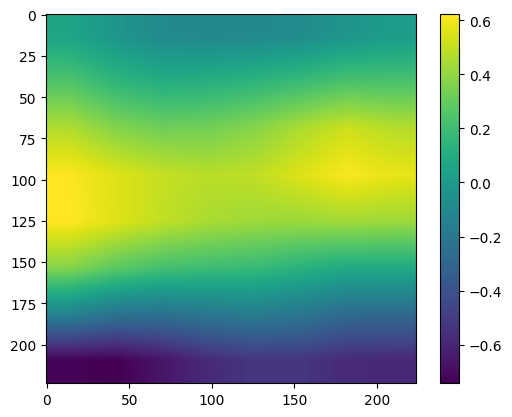

In [7]:
for batch in eddy_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1][2]

    plt.imshow(img)
    plt.colorbar()
    break

torch.Size([64, 3, 224, 224])


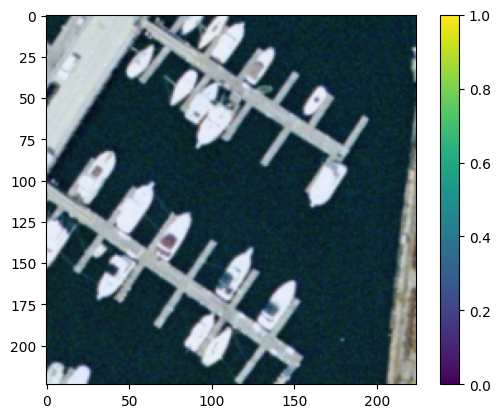

In [4]:
for batch in uc_merced_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break

torch.Size([64, 3, 224, 224])


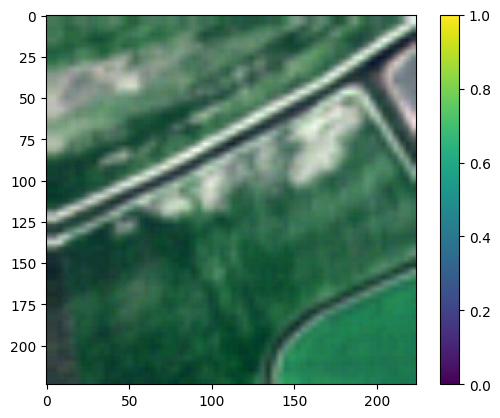

In [7]:
for batch in eruo_sat_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break


torch.Size([64, 3, 224, 224])


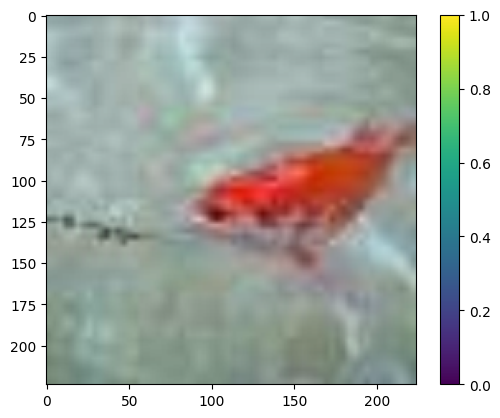

In [8]:
for batch in img_net_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break

# Features

In [5]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
model.eval()
model.to("cuda")

Using cache found in C:\Users\Jake Tallman/.cache\torch\hub\facebookresearch_dino_main
C:\Users\Jake Tallman\Desktop\Classes\ML\FinalProject\.venv\Lib\site-packages\torch\cuda\__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GeForce GTX 970 which is of cuda capability 5.2.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (6.1) - (9.0)
    
  warnings.warn(
C:\Users\Jake Tallman\Desktop\Classes\ML\FinalProject\.venv\Lib\site-packages\torch\cuda\__init__.py:304: UserWarning: 
    Please install PyTorch with a following CUDA
    configurations:  12.6 following instructions at
    https://pytorch.org/get-started/locally/
    
  warnings.warn(matched_cuda_warn.format(matched_arches))
C:\Users\Jake Tallman\Desktop\Classes\ML\FinalProject\.venv\Lib\site-packages\torch\cuda\__init__.py:326: UserWarning: 
NVIDIA GeForce GTX 970 with CUDA capability sm_52 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capa

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [ ]:
subsample_percent = 10
model.eval().to(device)

X_tiny_image_net, y_tiny_image_net = features.frozen_features(model, img_net_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_tiny_image_net, y_val_tiny_image_net = features.frozen_features(model, img_net_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

In [ ]:
subsample_percent = 10
model.eval().to(device)

X_eruosat_rgb, y_eruosat_rgb = features.frozen_features(model, eruo_sat_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_eruosat_rgb, y_val_eruosat_rgb = features.frozen_features(model, eruo_sat_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

In [7]:
subsample_percent = 10
model.eval().to(device)

X_uc_merced, y_uc_merced = features.frozen_features(model, uc_merced_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_uc_merced, y_val_uc_merced = features.frozen_features(model, uc_merced_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

  0%|          | 0/27 [00:00<?, ?it/s]


AcceleratorError: CUDA error: no kernel image is available for execution on the device
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


# Zero Shot

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

def knn_score(X, y, X_val, y_val, k=5):
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X, y)

    print(neigh.score(X_val, y_val))

In [ ]:
knn_score(X_tiny_image_net, y_tiny_image_net, X_val_tiny_image_net, y_val_tiny_image_net, k=5)

In [ ]:
knn_score(X_eruosat_rgb, y_eruosat_rgb, X_val_eruosat_rgb, y_val_eruosat_rgb, k=5)

In [ ]:
knn_score(X_uc_merced, y_uc_merced, X_val_uc_merced, y_val_uc_merced, k=5)